# Maclaurin Series

A Maclaurin series is a Taylor series centered at $x=0$. For a sufficiently differentiable function $f(x)$, its Maclaurin expansion is

$$
f(x) = \sum_{n=0}^{\infty}\frac{f^{(n)}(0)}{n!}x^n,
$$

where $f^{(n)}(0)$ denotes the $n$-th derivative of $f(x)$ evaluated at the origin. A finite number of terms provides a polynomial approximation of the original function. The approximation generally becomes more accurate as the degree is increased, particularly near the expansion point.


In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Maclaurin Expansion of $\sin(x)$

Consider

$$
f(x) = \sin(x).
$$

The derivatives of $\sin(x)$ evaluated at $x=0$ produce the expansion

$$
\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \frac{x^9}{9!}+\cdots.
$$

Using a polynomial of degree $9$ gives the approximation

$$
P_9(x) = x -\frac{x^3}{6} + \frac{x^5}{120} - \frac{x^7}{5040} + \frac{x^9}{362880}.
$$

The polynomial approximation is constructed from sampled values of $\sin(x)$ over the interval $[-\pi,\pi]$ using `np.polynomial.Polynomial.fit`.

In [3]:
x = np.linspace(-np.pi, np.pi, 1000)
f = np.sin(x)
deg = 9

In [4]:
P = np.polynomial.Polynomial.fit(x, f, deg=deg)
P

Polynomial([-2.32276799e-16,  3.14154380e+00, -5.01426066e-15, -5.16664838e+00,
        3.99478107e-14,  2.54371881e+00, -7.73092906e-14, -5.83350347e-01,
        4.31962725e-14,  6.47524286e-02], domain=[-3.14159265,  3.14159265], window=[-1.,  1.], symbol='x')

## Coefficient Verification

The coefficients of the fitted polynomial can be converted to the standard polynomial basis and compared with the analytical Maclaurin coefficients:

$$
\left[0, 1, 0, -\frac{1}{6}, 0, \frac{1}{120}, 0, -\frac{1}{5040}, 0, \frac{1}{362880} \right].
$$

The comparison is performed using `np.allclose`, allowing for small numerical differences introduced by floating-point computation.

In [5]:
np.allclose(P.convert().coef, np.array([0, 1, 0, -1/6, 0, 1/120, 0, -1/5040, 0, 1/362880]), rtol=1e-4, atol=1e-4)

True

## Approximation

The original function and its degree-$9$ Maclaurin approximation are evaluated over the interval $[-\pi,\pi]$ and plotted together.

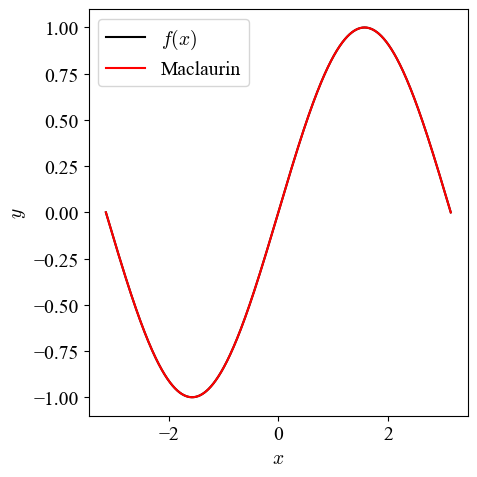

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(x, f, "k", label=r"$f(x)$")
plt.plot(x, P(x), "r", label="Maclaurin")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

The approximation follows $\sin(x)$ closely over the interval, while deviations become more apparent farther from the expansion point $x=0$. This illustrates the local nature of a finite Maclaurin approximation and the effect of truncating an infinite series to a polynomial of finite degree.